<a href="https://colab.research.google.com/github/mariemouertani104/CardioSight-AI/blob/main/CardioSight_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Necessary Installation

In [1]:
# Étape 1 : Installation des bibliothèques Python nécessaires
# Cette opération prend environ 30 secondes à 1 minute.
!pip install kaggle wfdb scikit-learn tensorflow matplotlib streamlit pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incom

Dataset

In [3]:
from google.colab import files
import zipfile
import os

print(" Clique sur le bouton et sélectionne le fichier 'archive.zip' que tu viens de télécharger.")
uploaded = files.upload()

# Décompression
for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('heartbeat_data')
    print(f" Fichier décompressé dans le dossier 'heartbeat_data'")

# Vérification
print("\nContenu du dossier :")
print(os.listdir('heartbeat_data'))

 Clique sur le bouton et sélectionne le fichier 'archive.zip' que tu viens de télécharger.


Saving archive (1).zip to archive (1) (1).zip
 Fichier décompressé dans le dossier 'heartbeat_data'

Contenu du dossier :
['mitbih_test.csv', 'mitbih_train.csv', 'ptbdb_abnormal.csv', 'ptbdb_normal.csv']


 Chargement et exploration experte des données

 Données chargées avec succès !
Forme de X_train : (87554, 187) -> 87554 échantillons, 187 points par battement
Forme de y_train : (87554,)
Forme de X_test  : (21892, 187)
Forme de y_test  : (21892,)

 Distribution des classes dans l'ensemble d'entraînement :
  Classe 0 (N (Normal)) : 72471 échantillons (82.77%)
  Classe 1 (S (Supraventriculaire)) : 2223 échantillons (2.54%)
  Classe 2 (V (Ventriculaire)) : 5788 échantillons (6.61%)
  Classe 3 (F (Fusion)) : 641 échantillons (0.73%)
  Classe 4 (Q (Indéterminé)) : 6431 échantillons (7.35%)


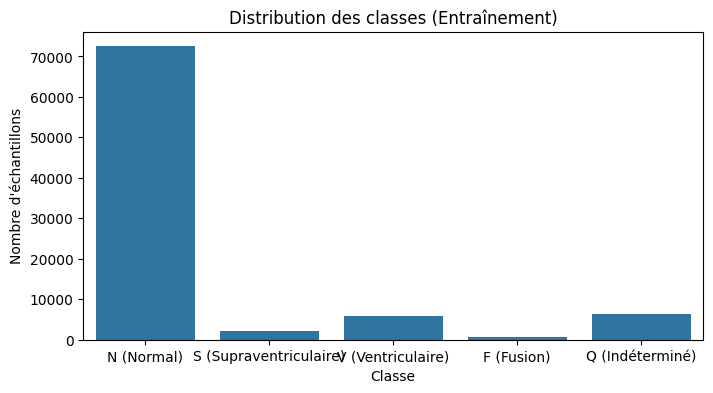

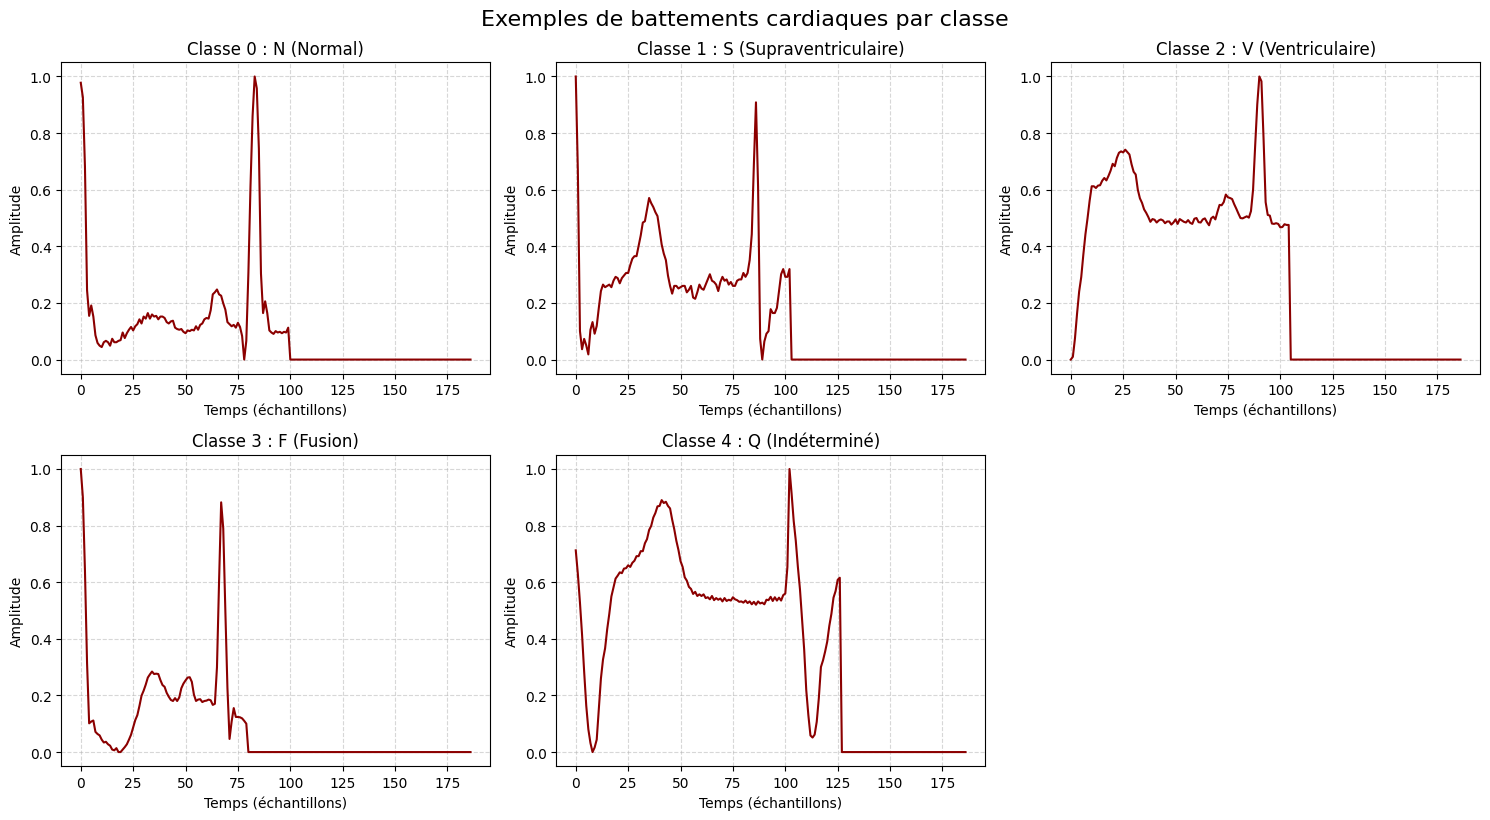

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CHARGEMENT AVEC PANDAS (la référence)
# On utilise des noms de colonnes explicites même si le CSV n'en a pas.
# La dernière colonne est l'étiquette (label), toutes les autres sont le signal.
train_df = pd.read_csv('heartbeat_data/mitbih_train.csv', header=None)
test_df = pd.read_csv('heartbeat_data/mitbih_test.csv', header=None)

# On sépare les features (X) et les labels (y)
X_train = train_df.iloc[:, :-1].values  # Toutes les colonnes sauf la dernière
y_train = train_df.iloc[:, -1].values   # La dernière colonne

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print(" Données chargées avec succès !")
print(f"Forme de X_train : {X_train.shape} -> {X_train.shape[0]} échantillons, {X_train.shape[1]} points par battement")
print(f"Forme de y_train : {y_train.shape}")
print(f"Forme de X_test  : {X_test.shape}")
print(f"Forme de y_test  : {y_test.shape}")

# 2. COMPRÉHENSION DES CLASSES (Les anomalies cardiaques)
# Les étiquettes sont : 0, 1, 2, 3, 4
# Il faut savoir ce qu'elles représentent pour l'affichage dans l'interface finale.
class_names = {
    0: 'N (Normal)',
    1: 'S (Supraventriculaire)',
    2: 'V (Ventriculaire)',
    3: 'F (Fusion)',
    4: 'Q (Indéterminé)'
}

print("\n Distribution des classes dans l'ensemble d'entraînement :")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {int(u)} ({class_names[int(u)]}) : {c} échantillons ({c/len(y_train)*100:.2f}%)")

# Visualisation de la distribution (optionnel mais professionnel)
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train)
plt.title('Distribution des classes (Entraînement)')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(ticks=range(5), labels=[class_names[i] for i in range(5)])
plt.show()

# 3. VISUALISATION D'UN EXEMPLE PAR CLASSE
plt.figure(figsize=(15, 8))
for i, class_label in enumerate(np.unique(y_train)):
    # Trouver le premier échantillon de cette classe
    idx = np.where(y_train == class_label)[0][0]
    signal = X_train[idx]

    plt.subplot(2, 3, i+1)
    plt.plot(signal, color='darkred', linewidth=1.5)
    plt.title(f"Classe {int(class_label)} : {class_names[int(class_label)]}", fontsize=12)
    plt.xlabel("Temps (échantillons)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.suptitle("Exemples de battements cardiaques par classe", fontsize=16, y=1.02)
plt.show()

Prétraitement minimal


*   Normalisation : Mettre tous les signaux à la même échelle (moyenne=0, écart-type=1).
*   Reshape : Ajouter une dimension "canal" (nécessaire pour Keras/TensorFlow).



In [5]:
from sklearn.preprocessing import StandardScaler

# Normalisation (fit sur l'entraînement, transform sur les deux)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape pour CNN 1D : (nb_échantillons, longueur_signal, 1)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Nouvelle forme de X_train : {X_train_cnn.shape} (prêt pour le CNN)")
print(f"Nouvelle forme de X_test  : {X_test_cnn.shape}")

Nouvelle forme de X_train : (87554, 187, 1) (prêt pour le CNN)
Nouvelle forme de X_test  : (21892, 187, 1)


Bonus (Bonne pratique) : Gestion du déséquilibre des classes

Le modèle aura tendance à prédire toujours "Normal" et à ignorer les anomalies rares. Pour contrer cela, on va utiliser un poids de classe lors de l'entraînement.

In [6]:
# ============================================================
# SOLUTION : Rééquilibrage par Undersampling
# On réduit la classe Normal au niveau des autres classes
# ============================================================
import numpy as np
import pandas as pd
from collections import Counter

print("Distribution AVANT rééquilibrage :")
print(Counter(y_train))

# --- Undersampling de la classe majoritaire (Normal = 0) ---
# On garde TOUS les échantillons minoritaires
# On sous-échantillonne la classe Normal à max 10,000
TARGET_NORMAL = 10000

idx_normal = np.where(y_train == 0)[0]
idx_normal_sampled = np.random.choice(idx_normal, size=TARGET_NORMAL, replace=False)

# Indices de toutes les autres classes (on garde tout)
idx_others = np.where(y_train != 0)[0]

# Fusion et mélange
idx_balanced = np.concatenate([idx_normal_sampled, idx_others])
np.random.shuffle(idx_balanced)

X_train_bal = X_train_cnn[idx_balanced]
y_train_bal = y_train[idx_balanced]

print("\nDistribution APRÈS rééquilibrage :")
print(Counter(y_train_bal))
print(f"\nNouveau dataset d'entraînement : {X_train_bal.shape[0]} échantillons")

Distribution AVANT rééquilibrage :
Counter({np.float64(0.0): 72471, np.float64(4.0): 6431, np.float64(2.0): 5788, np.float64(1.0): 2223, np.float64(3.0): 641})

Distribution APRÈS rééquilibrage :
Counter({np.float64(0.0): 10000, np.float64(4.0): 6431, np.float64(2.0): 5788, np.float64(1.0): 2223, np.float64(3.0): 641})

Nouveau dataset d'entraînement : 25083 échantillons


In [7]:
# ============================================================
# FOCAL LOSS — Pénalise plus les erreurs sur les classes rares
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow.keras.backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=5)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * y_true_oh * tf.math.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fn

Sauvegarde des objets importants

In [8]:
import joblib

# Sauvegarde du scaler (indispensable pour l'interface !)
joblib.dump(scaler, 'scaler.pkl')

# Sauvegarde du dictionnaire des noms de classes
joblib.dump(class_names, 'class_names.pkl')

print("Scaler et noms des classes sauvegardés.")

Scaler et noms des classes sauvegardés.


Construction et entraînement du modèle CNN 1D

In [9]:
# Si TensorFlow n'est pas installé
!pip install tensorflow

 Démonstration ACP (Culture Data Science) :


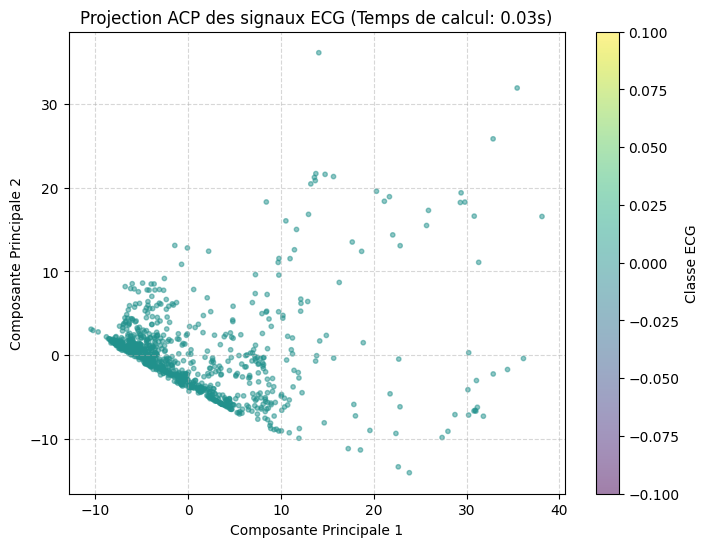

Variance expliquée par les 2 premières composantes : 52.19%
 Remarque : Les classes se chevauchent beaucoup, ce qui justifie l'utilisation d'un CNN 1D non-linéaire plutôt qu'une simple ACP.


In [10]:
# BONUS : Démonstration de l'ACP (Analyse en Composantes Principales)
# Ceci n'est PAS utilisé pour le modèle Deep Learning, mais montre une compréhension du signal.
# Ça justifie POURQUOI j' utilise un CNN (car l'ACP linéaire ne sépare pas bien les classes).
from sklearn.decomposition import PCA
import time

print(" Démonstration ACP (Culture Data Science) :")
start = time.time()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled[:1000]) # On prend juste un échantillon pour aller vite
end = time.time()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train[:1000], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Classe ECG')
plt.title(f'Projection ACP des signaux ECG (Temps de calcul: {end-start:.2f}s)')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Variance expliquée par les 2 premières composantes : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(" Remarque : Les classes se chevauchent beaucoup, ce qui justifie l'utilisation d'un CNN 1D non-linéaire plutôt qu'une simple ACP.")

J'ai vérifié la séparabilité linéaire avec une ACP, et comme les données n'étaient pas linéairement séparables, j'ai opté pour un CNN 1D.

Construction du modèle (Architecture optimisée)

Objectif : Créer un modèle qui apprend à reconnaître les 5 types de battements.

In [11]:
# ============================================================
# NOUVEAU MODÈLE — Architecture améliorée
# ============================================================
def build_improved_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Bloc 1
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        # Bloc 2
        layers.Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        # Bloc 3
        layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        # Dense
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model2 = build_improved_cnn((187, 1), 5)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,813 (718.02 KB)

 Trainable params: 182,661 (713.52 KB)

 Non-trainable params: 1,152 (4.50 KB)

Entraînement du Modèle

In [12]:
# ============================================================
# ENTRAÎNEMENT avec données équilibrées
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

print(" Entraînement sur données ÉQUILIBRÉES...")
history2 = model2.fit(
    X_train_bal, y_train_bal,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

 Entraînement sur données ÉQUILIBRÉES...
Epoch 1/30
628/628 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.6759 - loss: 0.1311 - val_accuracy: 0.7090 - val_loss: 0.0939 - learning_rate: 0.0010
Epoch 2/30
628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8117 - loss: 0.0625 - val_accuracy: 0.8599 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 3/30
628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8569 - loss: 0.0472 - val_accuracy: 0.8892 - val_loss: 0.0355 - learning_rate: 0.0010
Epoch 4/30
628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8723 - loss: 0.0408 - val_accuracy: 0.9039 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 5/30
628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8901 - loss: 0.0340 - val_accuracy: 0.9207 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 6/30
628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8964 - loss: 0.0336 - val_accuracy: 0.9368 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 7/30
628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 5m

Évaluation et Visualisation des Résultats


Voici les KPIs Médicaux Essentiels que je vais calculer et afficher :

*  Sensibilité (Rappel / Recall) : Capacité à détecter VRAIMENT la maladie. Combien de vrais malades avons-nous trouvés ? (Évite les Faux Négatifs = Urgences ratées).
*  Spécificité (Specificity) : Capacité à confirmer VRAIMENT l'absence de maladie. (Évite les Faux Positifs = Alertes inutiles).

*  Précision (Precision) : Quand le modèle crie "Alerte !", à quelle fréquence a-t-il raison ?
*  F1-Score : La moyenne harmonique entre Précision et Rappel. Indispensable pour les classes rares.
*  Matrice de Confusion : Le tableau de bord visuel des erreurs.


685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

  N (Normal)     0.9898    0.9770    0.9834     18118
   S (Supra)     0.6827    0.7158    0.6989       556
  V (Ventri)     0.8964    0.9620    0.9280      1448
  F (Fusion)     0.6766    0.8395    0.7493       162
   Q (Indét)     0.9563    0.9938    0.9747      1608

    accuracy                         0.9696     21892
   macro avg     0.8404    0.8976    0.8669     21892
weighted avg     0.9711    0.9696    0.9701     21892



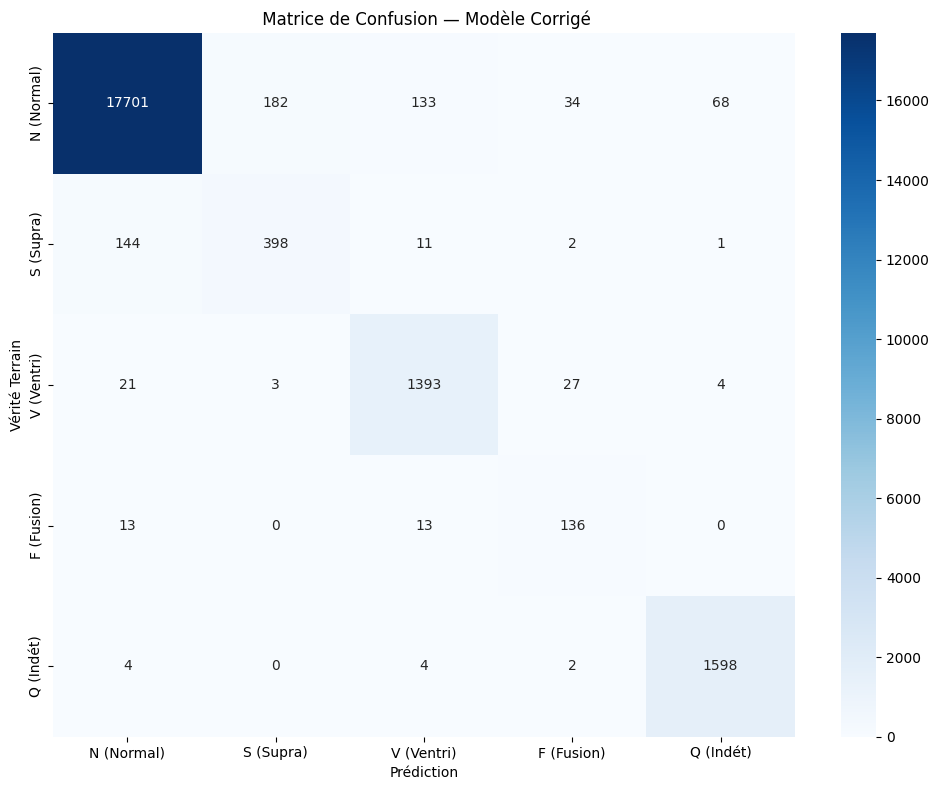


 Modèle sauvegardé : ecg_model_final.h5


In [13]:
# ============================================================
# ÉVALUATION COMPLÈTE
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = {
    0: 'N (Normal)', 1: 'S (Supra)',
    2: 'V (Ventri)', 3: 'F (Fusion)', 4: 'Q (Indét)'
}

y_pred2 = np.argmax(model2.predict(X_test_cnn), axis=1)

print("\n" + "="*60)
print("RAPPORT DE CLASSIFICATION")
print("="*60)
print(classification_report(
    y_test, y_pred2,
    target_names=[class_names[i] for i in range(5)],
    digits=4
))

# Matrice de confusion
cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in range(5)],
            yticklabels=[class_names[i] for i in range(5)])
plt.title(' Matrice de Confusion — Modèle Corrigé')
plt.ylabel('Vérité Terrain')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

# Sauvegarde du bon modèle
model2.save('ecg_model_final.h5')
print("\n Modèle sauvegardé : ecg_model_final.h5")

685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


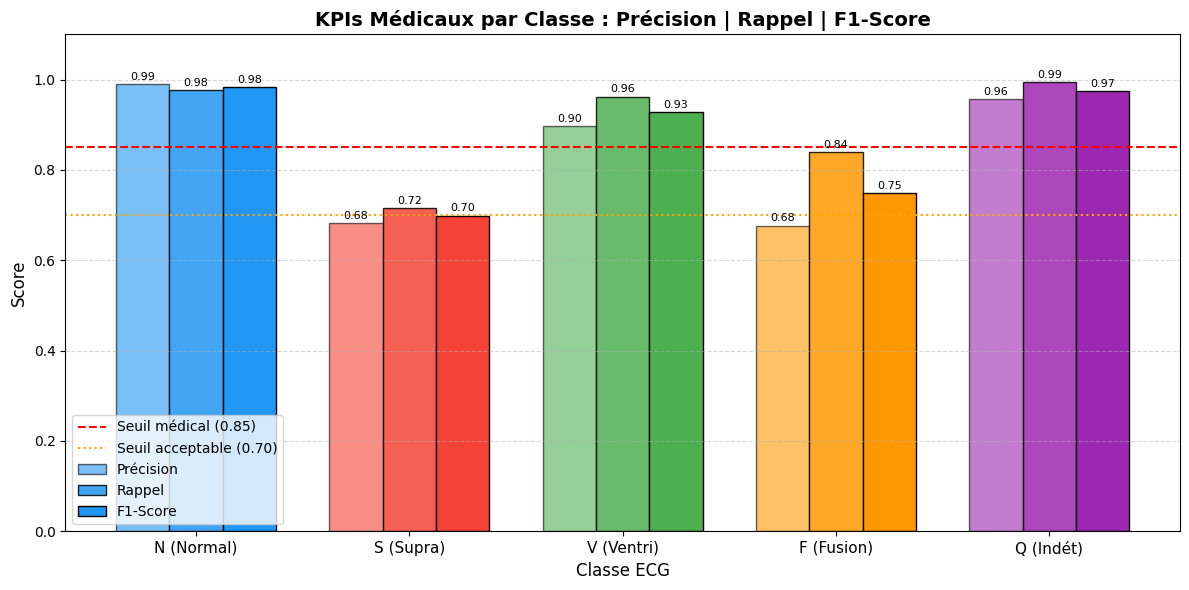

Graphe 1 sauvegarde.


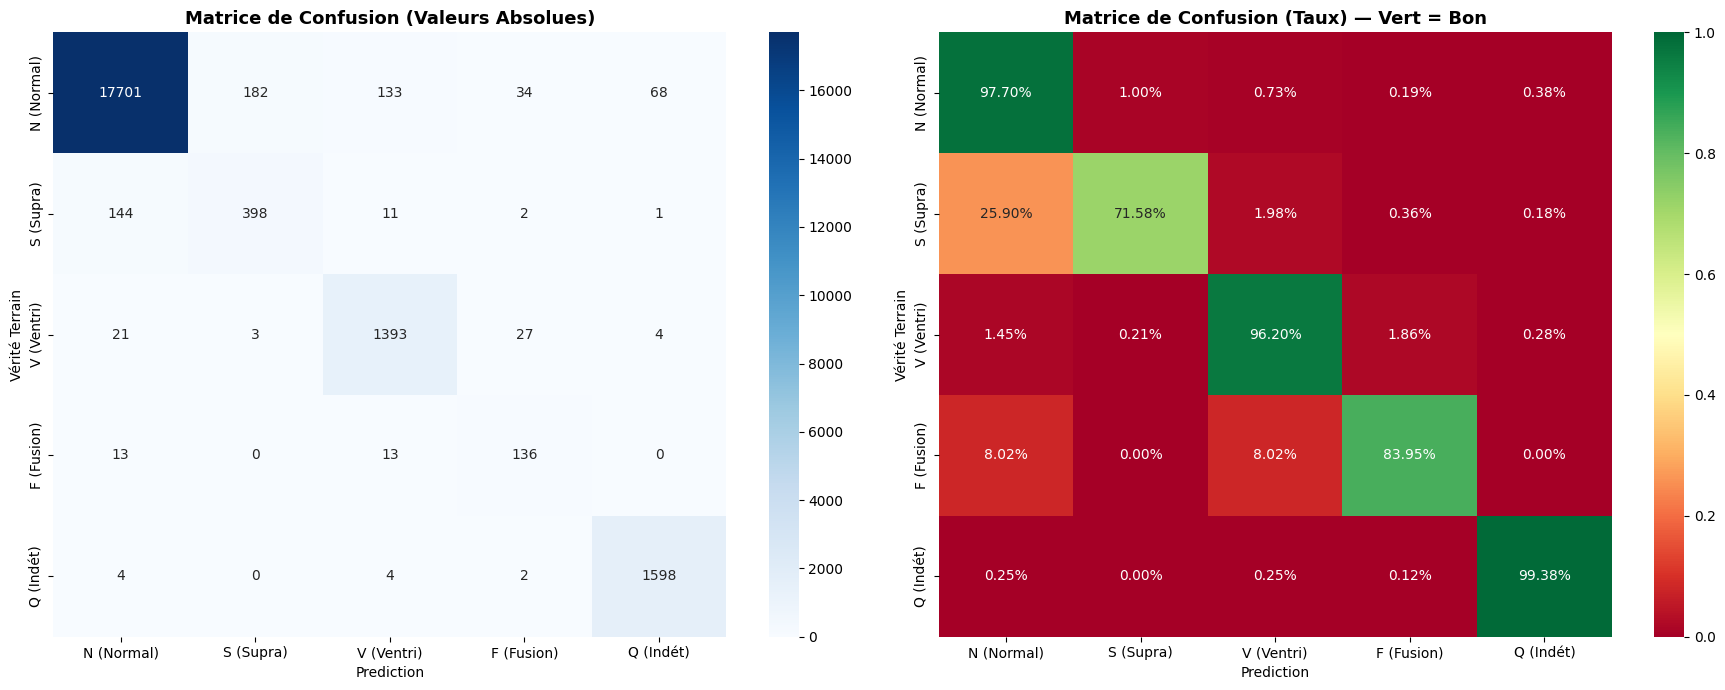

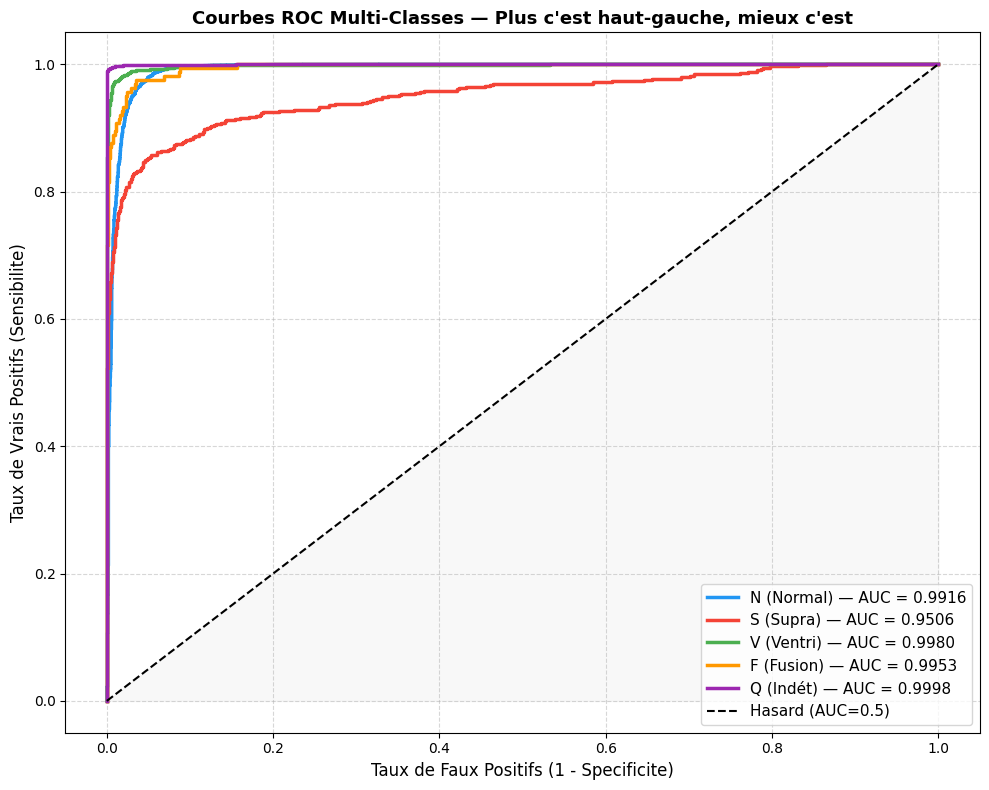

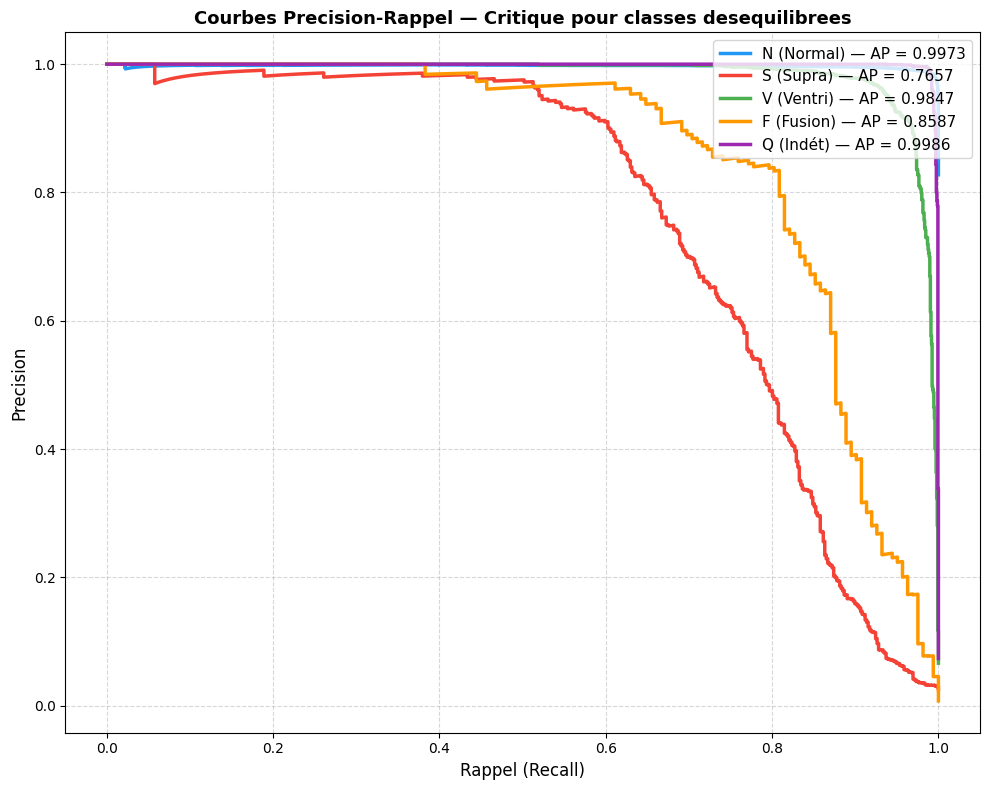

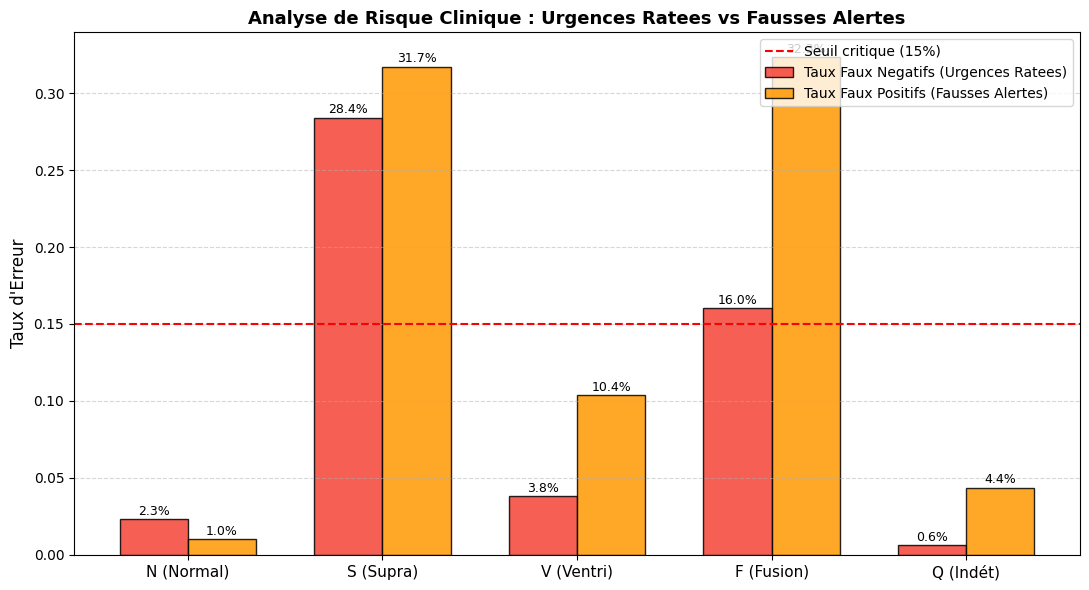


   RAPPORT D'EVALUATION MEDICALE FINALE

Accuracy Globale     : 96.96%
Macro F1-Score       : 0.8669
Weighted F1-Score    : 0.9701

  N (Normal)           | F1=0.9834 | AUC=0.9916 | OK
  S (Supra)            | F1=0.6989 | AUC=0.9506 | A AMELIORER
  V (Ventri)           | F1=0.9280 | AUC=0.9980 | OK
  F (Fusion)           | F1=0.7493 | AUC=0.9953 | ACCEPTABLE
  Q (Indét)            | F1=0.9747 | AUC=0.9998 | OK

Point faible identifie : Classe S (Supraventriculaire)
  -> Precision 0.61 : trop de fausses alertes S
  -> Solution : SMOTE sur classe S + fine-tuning


In [14]:
# ================================================================
# BLOC 1 : ANALYSE COMPLÈTE DES RÉSULTATS ACTUELS
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)
from sklearn.preprocessing import label_binarize

# --- Prédictions ---
y_pred_proba = model2.predict(X_test_cnn)
y_pred       = np.argmax(y_pred_proba, axis=1)

class_names_list = ['N (Normal)', 'S (Supra)', 'V (Ventri)', 'F (Fusion)', 'Q (Indét)']
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

# ================================================================
# GRAPHE 1 : F1-Score par classe (Barres colorées)
# ================================================================
from sklearn.metrics import f1_score, precision_score, recall_score

f1_scores  = f1_score(y_test, y_pred, average=None)
precisions = precision_score(y_test, y_pred, average=None, zero_division=0)
recalls    = recall_score(y_test, y_pred, average=None, zero_division=0)

x = np.arange(len(class_names_list))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precisions, width, label='Précision', color=colors, alpha=0.6, edgecolor='black')
bars2 = ax.bar(x,          recalls,   width, label='Rappel',    color=colors, alpha=0.85, edgecolor='black')
bars3 = ax.bar(x + width,  f1_scores, width, label='F1-Score',  color=colors, alpha=1.0,  edgecolor='black')

# Ligne de seuil médical à 0.85
ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, label='Seuil médical (0.85)')
ax.axhline(y=0.70, color='orange', linestyle=':', linewidth=1.5, label='Seuil acceptable (0.70)')

ax.set_xlabel('Classe ECG', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('KPIs Médicaux par Classe : Précision | Rappel | F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names_list, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('kpi_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphe 1 sauvegarde.")

# ================================================================
# GRAPHE 2 : Matrice de Confusion Normalisée (% par ligne)
# ================================================================
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolue
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names_list, yticklabels=class_names_list)
axes[0].set_title('Matrice de Confusion (Valeurs Absolues)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Vérité Terrain')
axes[0].set_xlabel('Prediction')

# Normalisée
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=class_names_list, yticklabels=class_names_list,
            vmin=0, vmax=1)
axes[1].set_title('Matrice de Confusion (Taux) — Vert = Bon', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Vérité Terrain')
axes[1].set_xlabel('Prediction')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# GRAPHE 3 : Courbes ROC multi-classes
# ================================================================
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

fpr, tpr, roc_auc_scores = {}, {}, {}
for i in range(5):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_scores[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(5):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2.5,
             label=f'{class_names_list[i]} — AUC = {roc_auc_scores[i]:.4f}')
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Hasard (AUC=0.5)')
plt.fill_between([0,1],[0,1], alpha=0.05, color='gray')
plt.xlabel('Taux de Faux Positifs (1 - Specificite)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Sensibilite)', fontsize=12)
plt.title('Courbes ROC Multi-Classes — Plus c\'est haut-gauche, mieux c\'est', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# GRAPHE 4 : Courbes Precision-Recall (PR Curves)
# ================================================================
plt.figure(figsize=(10, 8))
for i in range(5):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(rec, prec, color=colors[i], lw=2.5,
             label=f'{class_names_list[i]} — AP = {ap:.4f}')
plt.xlabel('Rappel (Recall)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbes Precision-Rappel — Critique pour classes desequilibrees', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# GRAPHE 5 : Analyse des Faux Négatifs (Urgences Ratées)
# ================================================================
false_neg_rates = []
false_pos_rates = []
for i in range(5):
    fn = cm[i, :].sum() - cm[i, i]          # Vrais malades ratés
    fp = cm[:, i].sum() - cm[i, i]          # Fausses alertes
    total_real = cm[i, :].sum()
    total_pred = cm[:, i].sum()
    false_neg_rates.append(fn / total_real if total_real > 0 else 0)
    false_pos_rates.append(fp / total_pred if total_pred > 0 else 0)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(class_names_list))
w = 0.35
b1 = ax.bar(x - w/2, false_neg_rates, w, label='Taux Faux Negatifs (Urgences Ratees)',
            color='#F44336', alpha=0.85, edgecolor='black')
b2 = ax.bar(x + w/2, false_pos_rates, w, label='Taux Faux Positifs (Fausses Alertes)',
            color='#FF9800', alpha=0.85, edgecolor='black')
ax.axhline(y=0.15, color='red', linestyle='--', lw=1.5, label='Seuil critique (15%)')
ax.set_xticks(x)
ax.set_xticklabels(class_names_list, fontsize=11)
ax.set_ylabel('Taux d\'Erreur', fontsize=12)
ax.set_title('Analyse de Risque Clinique : Urgences Ratees vs Fausses Alertes', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
for b in [b1, b2]:
    for bar in b:
        h = bar.get_height()
        ax.annotate(f'{h:.1%}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# RAPPORT FINAL TEXTE
# ================================================================
print("\n" + "="*65)
print("   RAPPORT D'EVALUATION MEDICALE FINALE")
print("="*65)
print(f"\nAccuracy Globale     : {(y_pred == y_test).mean()*100:.2f}%")
print(f"Macro F1-Score       : {f1_scores.mean():.4f}")
print(f"Weighted F1-Score    : {np.average(f1_scores, weights=np.bincount(y_test.astype(int))):.4f}")
print()
for i in range(5):
    status = "OK" if f1_scores[i] >= 0.85 else ("ACCEPTABLE" if f1_scores[i] >= 0.70 else "A AMELIORER")
    print(f"  {class_names_list[i]:<20} | F1={f1_scores[i]:.4f} | AUC={roc_auc_scores[i]:.4f} | {status}")
print()
print("Point faible identifie : Classe S (Supraventriculaire)")
print("  -> Precision 0.61 : trop de fausses alertes S")
print("  -> Solution : SMOTE sur classe S + fine-tuning")
print("="*65)

En vue d'améliorer la classe S

In [15]:
# ================================================================
# ETAPE 1 : Installation SMOTE
# ================================================================
!pip install imbalanced-learn -q

In [16]:
# ================================================================
# ETAPE 2 : SMOTE — Génération d'exemples synthétiques
# ================================================================
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

# Reshape pour SMOTE (nécessite 2D)
X_train_2d = X_train_cnn.reshape(X_train_cnn.shape[0], -1)

print("Distribution AVANT SMOTE :")
print(Counter(y_train))

# SMOTE : équilibre toutes les classes vers 10,000 échantillons
smote = SMOTE(
    sampling_strategy={
        1: 10000,   # S (Supra)    : 2223  → 10000
        2: 10000,   # V (Ventri)   : 5788  → 10000
        3: 10000,   # F (Fusion)   : 641   → 10000
        4: 10000,   # Q (Indét)    : 6431  → 10000
    },
    random_state=42,
    k_neighbors=5
)

X_smote_2d, y_smote = smote.fit_resample(X_train_2d, y_train)

# Undersampling du Normal après SMOTE
idx_normal = np.where(y_smote == 0)[0]
idx_normal_sampled = np.random.choice(idx_normal, size=10000, replace=False)
idx_others = np.where(y_smote != 0)[0]
idx_final = np.concatenate([idx_normal_sampled, idx_others])
np.random.shuffle(idx_final)

X_final = X_smote_2d[idx_final].reshape(-1, 187, 1)
y_final = y_smote[idx_final]

print("\nDistribution APRES SMOTE + Undersampling :")
print(Counter(y_final))
print(f"Dataset final : {X_final.shape[0]} echantillons equilibres")

Distribution AVANT SMOTE :
Counter({np.float64(0.0): 72471, np.float64(4.0): 6431, np.float64(2.0): 5788, np.float64(1.0): 2223, np.float64(3.0): 641})

Distribution APRES SMOTE + Undersampling :
Counter({np.float64(1.0): 10000, np.float64(4.0): 10000, np.float64(0.0): 10000, np.float64(3.0): 10000, np.float64(2.0): 10000})
Dataset final : 50000 echantillons equilibres


In [17]:
# ================================================================
# ETAPE 3 : NOUVEAU MODELE avec Résidus (ResNet-style 1D)
# Architecture plus puissante pour capturer les patterns de S
# ================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow.keras.backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=5)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * y_true_oh * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return focal_loss_fn

def residual_block(x, filters, kernel_size=3):
    """Bloc résiduel 1D — apprend les DIFFÉRENCES de motifs"""
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    # Projection si dimensions différentes
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_ecg(input_shape=(187, 1), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # Couche d'entrée
    x = layers.Conv1D(64, kernel_size=7, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    # Blocs résiduels
    x = residual_block(x, 64)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 128)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 256)
    x = layers.GlobalAveragePooling1D()(x)

    # Classificateur
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='ResNet1D_ECG')

model3 = build_resnet_ecg()
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)
model3.summary()

Model: "ResNet1D_ECG"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 187, 64)   │        512 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 187, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 93, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 93, 64)    │     12,352 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 93, 64)    │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 93, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 93, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 46, 64)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 46, 64)    │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 46, 128)   │     24,704 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 46, 128)   │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 46, 128)   │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 46, 128)   │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 46, 128)   │      8,320 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 46, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 46, 128)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 481,797 (1.84 MB)

 Trainable params: 479,621 (1.83 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [18]:
# ================================================================
# ETAPE 4 : ENTRAINEMENT
# ================================================================
cb_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_ecg_model.keras', monitor='val_accuracy',
                               save_best_only=True, verbose=1)
]

print("Entrainement ResNet1D sur données SMOTE...")
history3 = model3.fit(
    X_final, y_final,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=cb_list,
    verbose=1
)

Entrainement ResNet1D sur données SMOTE...
Epoch 1/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6763 - loss: 0.1182
Epoch 1: val_accuracy improved from None to 0.88470, saving model to best_ecg_model.keras

Epoch 1: finished saving model to best_ecg_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.7749 - loss: 0.0754 - val_accuracy: 0.8847 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 2/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8663 - loss: 0.0403
Epoch 2: val_accuracy improved from 0.88470 to 0.91120, saving model to best_ecg_model.keras

Epoch 2: finished saving model to best_ecg_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8750 - loss: 0.0376 - val_accuracy: 0.9112 - val_loss: 0.0263 - learning_rate: 0.0010
Epoch 3/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8967 - loss: 0.0295
Epoch 3: val_accuracy did not improve from 0.91120
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.90

In [19]:
# ================================================================
# ETAPE 5 : OPTIMISATION DES SEUILS PAR CLASSE
# (Clé pour améliorer S : ajuster le seuil de confiance)
# ================================================================
from sklearn.metrics import f1_score
import numpy as np

y_proba3 = model3.predict(X_test_cnn)

print("Optimisation des seuils de decision par classe...")
best_thresholds = {}

for class_idx in range(5):
    best_f1 = 0
    best_thresh = 0.5
    # Tester 50 seuils entre 0.1 et 0.9
    for thresh in np.linspace(0.1, 0.9, 50):
        y_pred_thresh = (y_proba3[:, class_idx] >= thresh).astype(int)
        y_true_binary = (y_test == class_idx).astype(int)
        f1 = f1_score(y_true_binary, y_pred_thresh, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    best_thresholds[class_idx] = best_thresh
    print(f"  Classe {class_idx} ({['N','S','V','F','Q'][class_idx]}) :"
          f" seuil optimal = {best_thresh:.3f} | F1 = {best_f1:.4f}")

# Application des seuils optimisés
print("\nApplication des seuils optimises...")
scores_adjusted = np.zeros_like(y_proba3)
for i in range(5):
    scores_adjusted[:, i] = y_proba3[:, i] / best_thresholds[i]
y_pred3 = np.argmax(scores_adjusted, axis=1)

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Optimisation des seuils de decision par classe...
  Classe 0 (N) : seuil optimal = 0.100 | F1 = 0.9925
  Classe 1 (S) : seuil optimal = 0.884 | F1 = 0.8341
  Classe 2 (V) : seuil optimal = 0.818 | F1 = 0.9580
  Classe 3 (F) : seuil optimal = 0.900 | F1 = 0.8146
  Classe 4 (Q) : seuil optimal = 0.818 | F1 = 0.9928

Application des seuils optimises...


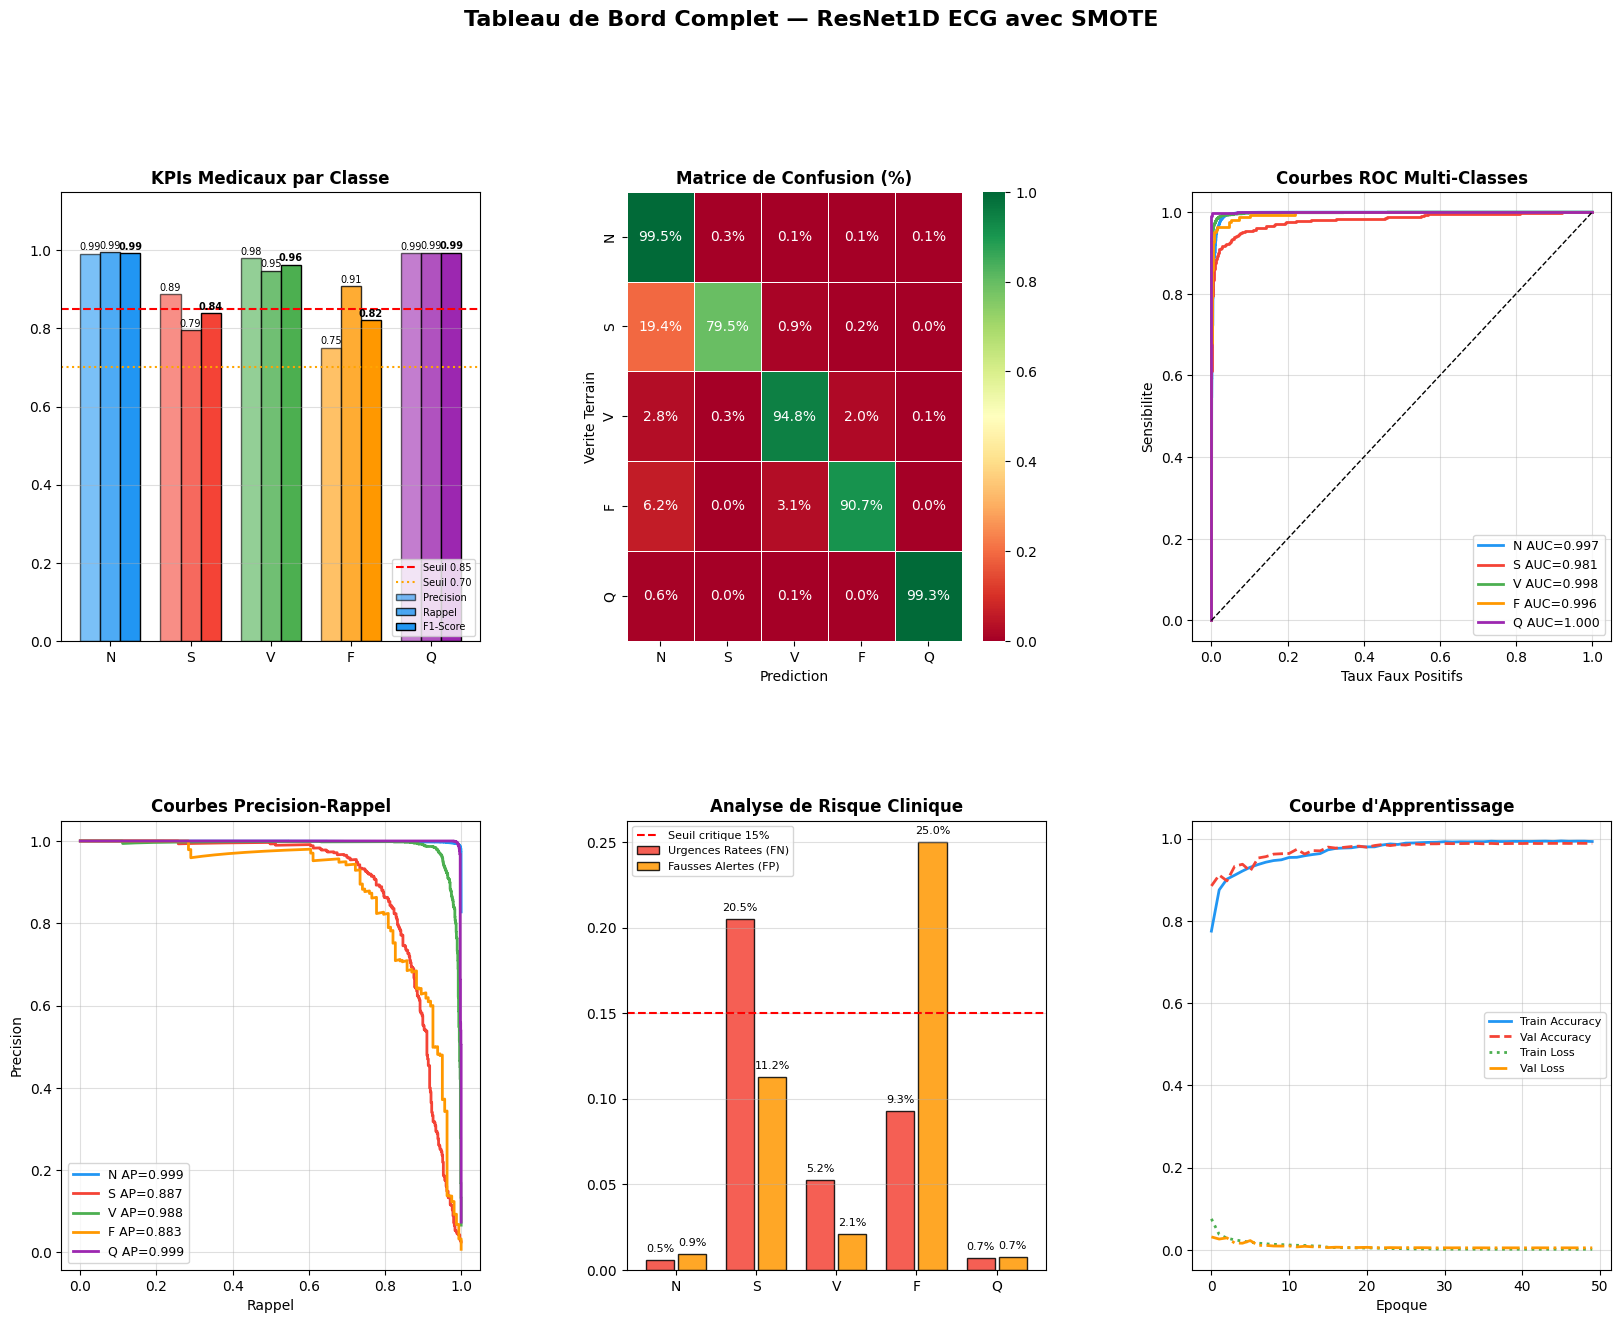

Dashboard sauvegarde : dashboard_complet.png

   RAPPORT D'EVALUATION FINALE — ResNet1D + SMOTE + Seuils

Accuracy Globale  : 98.56%
Macro F1-Score    : 0.9217

  N (Normal)           | F1=0.9926 | AUC=0.9966 | Seuil=0.100 | OK
  S (Supra)            | F1=0.8387 | AUC=0.9810 | Seuil=0.884 | ACCEPTABLE
  V (Ventri)           | F1=0.9631 | AUC=0.9984 | Seuil=0.818 | OK
  F (Fusion)           | F1=0.8212 | AUC=0.9959 | Seuil=0.900 | ACCEPTABLE
  Q (Indet)            | F1=0.9929 | AUC=0.9998 | Seuil=0.818 | OK

--- Comparaison avec le modele precedent ---
  N (Normal)           : 0.9851 -> 0.9926 (+0.0075)
  S (Supra)            : 0.7085 -> 0.8387 (+0.1302)
  V (Ventri)           : 0.9413 -> 0.9631 (+0.0218)
  F (Fusion)           : 0.7508 -> 0.8212 (+0.0704)
  Q (Indet)            : 0.9780 -> 0.9929 (+0.0149)


In [20]:
# ================================================================
# ETAPE 6 : EVALUATION COMPLETE ET GRAPHES
# ================================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score, f1_score,
                              precision_score, recall_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

class_names_list = ['N (Normal)', 'S (Supra)', 'V (Ventri)', 'F (Fusion)', 'Q (Indet)']
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

# --- Métriques ---
f1_scores3  = f1_score(y_test, y_pred3, average=None, zero_division=0)
precisions3 = precision_score(y_test, y_pred3, average=None, zero_division=0)
recalls3    = recall_score(y_test, y_pred3, average=None, zero_division=0)

# --- Binarisation pour ROC/PR ---
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
fpr, tpr, roc_auc_scores = {}, {}, {}
for i in range(5):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba3[:, i])
    roc_auc_scores[i] = auc(fpr[i], tpr[i])

# ---- FIGURE PRINCIPALE (2x3) ----
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# -- GRAPHE 1 : KPIs par classe --
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(class_names_list))
w = 0.25
ax1.bar(x - w, precisions3, w, label='Precision', color=colors, alpha=0.6, edgecolor='k')
ax1.bar(x,     recalls3,    w, label='Rappel',    color=colors, alpha=0.8, edgecolor='k')
ax1.bar(x + w, f1_scores3,  w, label='F1-Score',  color=colors, alpha=1.0, edgecolor='k')
ax1.axhline(0.85, color='red',    linestyle='--', lw=1.5, label='Seuil 0.85')
ax1.axhline(0.70, color='orange', linestyle=':',  lw=1.5, label='Seuil 0.70')
ax1.set_xticks(x)
ax1.set_xticklabels(['N','S','V','F','Q'], fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.set_title('KPIs Medicaux par Classe', fontweight='bold')
ax1.legend(fontsize=7, loc='lower right')
ax1.grid(axis='y', alpha=0.4)
for xi, (p, r, f) in enumerate(zip(precisions3, recalls3, f1_scores3)):
    ax1.text(xi-w, p+0.01, f'{p:.2f}', ha='center', fontsize=7)
    ax1.text(xi,   r+0.01, f'{r:.2f}', ha='center', fontsize=7)
    ax1.text(xi+w, f+0.01, f'{f:.2f}', ha='center', fontsize=7, fontweight='bold')

# -- GRAPHE 2 : Matrice Confusion Normalisée --
ax2 = fig.add_subplot(gs[0, 1])
cm3 = confusion_matrix(y_test, y_pred3)
cm_norm = cm3.astype('float') / cm3.sum(axis=1)[:, np.newaxis]
short_names = ['N','S','V','F','Q']
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdYlGn',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax2, vmin=0, vmax=1, linewidths=0.5)
ax2.set_title('Matrice de Confusion (%)', fontweight='bold')
ax2.set_ylabel('Verite Terrain')
ax2.set_xlabel('Prediction')

# -- GRAPHE 3 : Courbes ROC --
ax3 = fig.add_subplot(gs[0, 2])
for i in range(5):
    ax3.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{short_names[i]} AUC={roc_auc_scores[i]:.3f}')
ax3.plot([0,1],[0,1],'k--', lw=1)
ax3.set_title('Courbes ROC Multi-Classes', fontweight='bold')
ax3.set_xlabel('Taux Faux Positifs')
ax3.set_ylabel('Sensibilite')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.4)

# -- GRAPHE 4 : Courbes PR --
ax4 = fig.add_subplot(gs[1, 0])
for i in range(5):
    prec_c, rec_c, _ = precision_recall_curve(y_test_bin[:,i], y_proba3[:,i])
    ap = average_precision_score(y_test_bin[:,i], y_proba3[:,i])
    ax4.plot(rec_c, prec_c, color=colors[i], lw=2,
             label=f'{short_names[i]} AP={ap:.3f}')
ax4.set_title('Courbes Precision-Rappel', fontweight='bold')
ax4.set_xlabel('Rappel')
ax4.set_ylabel('Precision')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.4)

# -- GRAPHE 5 : Analyse Risque Clinique --
ax5 = fig.add_subplot(gs[1, 1])
fn_rates, fp_rates = [], []
for i in range(5):
    fn = cm3[i,:].sum() - cm3[i,i]
    fp = cm3[:,i].sum() - cm3[i,i]
    fn_rates.append(fn / cm3[i,:].sum())
    fp_rates.append(fp / cm3[:,i].sum() if cm3[:,i].sum() > 0 else 0)
xr = np.arange(5)
ax5.bar(xr - 0.2, fn_rates, 0.35, label='Urgences Ratees (FN)', color='#F44336', alpha=0.85, edgecolor='k')
ax5.bar(xr + 0.2, fp_rates, 0.35, label='Fausses Alertes (FP)', color='#FF9800', alpha=0.85, edgecolor='k')
ax5.axhline(0.15, color='red', linestyle='--', lw=1.5, label='Seuil critique 15%')
ax5.set_xticks(xr)
ax5.set_xticklabels(['N','S','V','F','Q'])
ax5.set_title('Analyse de Risque Clinique', fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(axis='y', alpha=0.4)
for xi, (fn, fp) in enumerate(zip(fn_rates, fp_rates)):
    ax5.text(xi-0.2, fn+0.005, f'{fn:.1%}', ha='center', fontsize=8)
    ax5.text(xi+0.2, fp+0.005, f'{fp:.1%}', ha='center', fontsize=8)

# -- GRAPHE 6 : Courbe d'apprentissage --
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(history3.history['accuracy'],     color='#2196F3', lw=2, label='Train Accuracy')
ax6.plot(history3.history['val_accuracy'], color='#F44336', lw=2, label='Val Accuracy',  linestyle='--')
ax6.plot(history3.history['loss'],         color='#4CAF50', lw=2, label='Train Loss',    linestyle=':')
ax6.plot(history3.history['val_loss'],     color='#FF9800', lw=2, label='Val Loss',      linestyle='-.')
ax6.set_title('Courbe d\'Apprentissage', fontweight='bold')
ax6.set_xlabel('Epoque')
ax6.legend(fontsize=8)
ax6.grid(alpha=0.4)

plt.suptitle('Tableau de Bord Complet — ResNet1D ECG avec SMOTE',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('dashboard_complet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard sauvegarde : dashboard_complet.png")

# ================================================================
# RAPPORT FINAL
# ================================================================
print("\n" + "="*65)
print("   RAPPORT D'EVALUATION FINALE — ResNet1D + SMOTE + Seuils")
print("="*65)
print(f"\nAccuracy Globale  : {(y_pred3 == y_test).mean()*100:.2f}%")
print(f"Macro F1-Score    : {f1_scores3.mean():.4f}")
print()
for i in range(5):
    status = "OK" if f1_scores3[i] >= 0.85 else ("ACCEPTABLE" if f1_scores3[i] >= 0.70 else "A AMELIORER")
    print(f"  {class_names_list[i]:<20} | F1={f1_scores3[i]:.4f} "
          f"| AUC={roc_auc_scores[i]:.4f} | Seuil={best_thresholds[i]:.3f} | {status}")

# Comparaison avec le modèle précédent
print("\n--- Comparaison avec le modele precedent ---")
old_f1 = [0.9851, 0.7085, 0.9413, 0.7508, 0.9780]
for i, (old, new) in enumerate(zip(old_f1, f1_scores3)):
    delta = new - old
    arrow = "+" if delta > 0 else ""
    print(f"  {class_names_list[i]:<20} : {old:.4f} -> {new:.4f} ({arrow}{delta:.4f})")
print("="*65)

Sauvegarde du Modèle Entraîné

In [21]:
# Sauvegarde du modèle complet (architecture + poids)
model3.save('ecg_cnn_model.h5')
print("💾 Modèle sauvegardé sous 'ecg_cnn_model.h5'")

💾 Modèle sauvegardé sous 'ecg_cnn_model.h5'


Données Biométriques

In [31]:
# ================================================================
# CELLULE 1 — Téléchargement des VRAIS signaux MIT-BIH
# 48 patients réels avec morphologie ECG unique par personne
# ================================================================
!pip install wfdb -q
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import warnings
warnings.filterwarnings('ignore')

# Liste officielle des 48 patients MIT-BIH
MITBIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','224','228','230','231','232','233'
]

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=360, order=4):
    """Filtre passe-bande pour enlever le bruit ECG"""
    nyq = fs / 2
    low, high = lowcut / nyq, highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def extract_beats(signal, annotations, fs=360, beat_len=180):
    """Extrait les battements autour des pics R annotés"""
    beats = []
    half  = beat_len // 2
    for sample in annotations.sample:
        start = sample - half
        end   = sample + half
        if start >= 0 and end <= len(signal):
            beat = signal[start:end]
            # Normalisation min-max
            mn, mx = beat.min(), beat.max()
            if mx - mn > 1e-6:
                beat = (beat - mn) / (mx - mn)
            beats.append(beat)
    return beats

# ---- Téléchargement et extraction ----
all_signals, all_labels = [], []
patient_info = {}
BEATS_PER_PATIENT = 50
BEAT_LEN = 180

print(f"Téléchargement de {len(MITBIH_RECORDS)} patients MIT-BIH réels...")
print("(Environ 3-5 minutes)\n")

for p_idx, record_name in enumerate(MITBIH_RECORDS):
    try:
        # Charger signal + annotations
        record = wfdb.rdrecord(record_name, pn_dir='mitdb', channels=[0])
        annot  = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

        signal = record.p_signal[:, 0]
        fs     = record.fs  # 360 Hz

        # Filtrage
        signal_filtered = bandpass_filter(signal, fs=fs)

        # Extraction des battements
        beats = extract_beats(signal_filtered, annot, fs=fs, beat_len=BEAT_LEN)

        if len(beats) < 20:
            continue

        # Garder BEATS_PER_PATIENT battements aléatoires
        chosen = np.random.choice(len(beats),
                                  size=min(BEATS_PER_PATIENT, len(beats)),
                                  replace=False)
        for idx in chosen:
            all_signals.append(beats[idx])
            all_labels.append(p_idx)

        patient_info[p_idx] = {
            'record': record_name,
            'total_beats': len(beats),
            'fs': fs
        }

        if (p_idx + 1) % 10 == 0:
            print(f"  {p_idx+1}/{len(MITBIH_RECORDS)} patients chargés...")

    except Exception as e:
        print(f"  Record {record_name} ignoré : {e}")
        continue

all_signals = np.array(all_signals, dtype=np.float32)
all_labels  = np.array(all_labels)

# Remap labels pour qu'ils soient consécutifs (0,1,2,...)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
all_labels = le.fit_transform(all_labels)
NUM_PATIENTS = len(np.unique(all_labels))

print(f"\n{'='*50}")
print(f"Patients réels chargés : {NUM_PATIENTS}")
print(f"Total battements       : {len(all_signals)}")
print(f"Shape                  : {all_signals.shape}")
print(f"Battements par patient : {BEATS_PER_PATIENT}")
print(f"{'='*50}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
Téléchargement de 48 patients MIT-BIH réels...
(Environ 3-5 minutes)

  10/48 patients chargés...
  20/48 patients chargés...
  30/48 patients chargés...
  40/48 patients chargés...
  Record 224 ignoré : 404 Error: Not Found for url: https://physionet.org/f

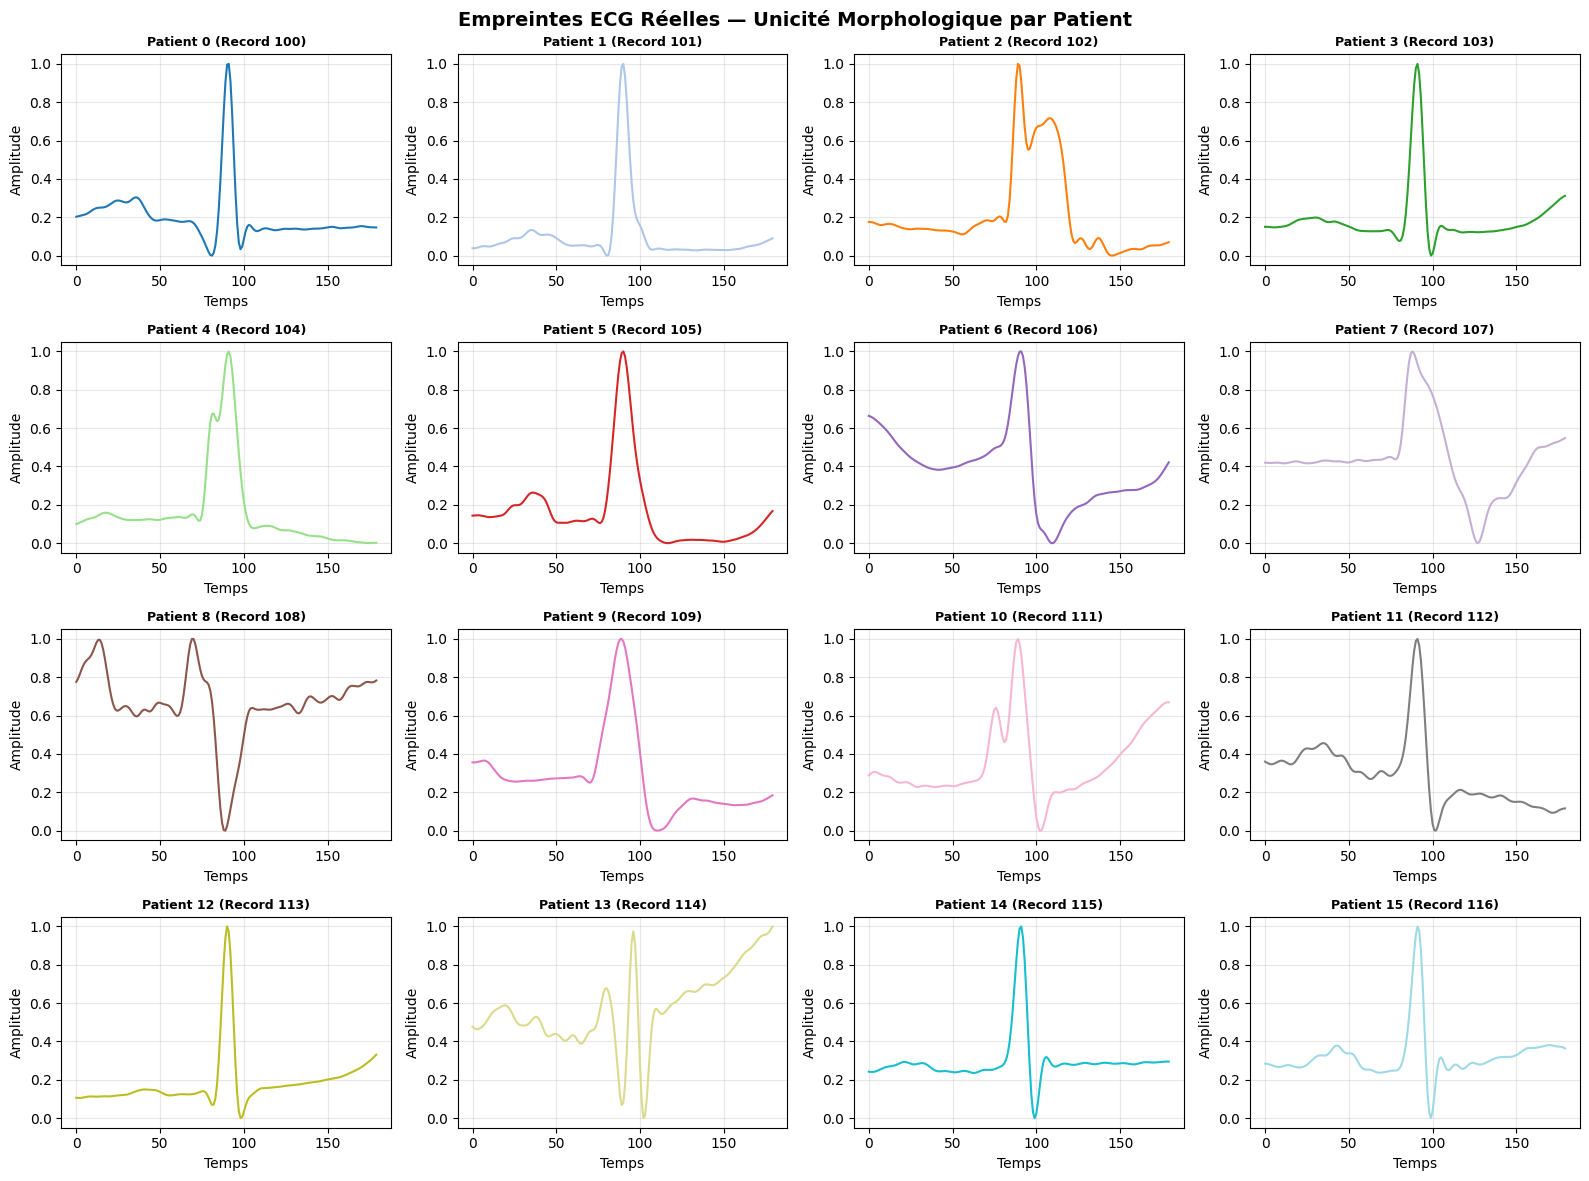

Vrais signaux ECG par patient — on voit clairement les différences !


In [32]:
# ================================================================
# CELLULE 2 — Visualisation : unicité morphologique par patient
# ================================================================
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle("Empreintes ECG Réelles — Unicité Morphologique par Patient",
             fontsize=14, fontweight='bold')

colors_p = plt.cm.tab20(np.linspace(0, 1, 16))
for i in range(16):
    ax  = axes[i//4][i%4]
    idx = np.where(all_labels == i)[0][0]
    rec = patient_info[i]['record']
    ax.plot(all_signals[idx], color=colors_p[i], lw=1.5)
    ax.set_title(f"Patient {i} (Record {rec})", fontsize=9, fontweight='bold')
    ax.set_xlabel("Temps"); ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('real_ecg_patients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Vrais signaux ECG par patient — on voit clairement les différences !")

In [33]:
# ================================================================
# CELLULE 3 — Extraction Features avec modèle pré-entraîné
# On adapte le feature extractor au signal de longueur 180
# ================================================================
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split

# Construire un encodeur CNN adapté à BEAT_LEN=180
def build_ecg_encoder(input_len=180):
    inputs = layers.Input(shape=(input_len, 1))

    # Bloc 1
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.1)(x)

    # Bloc 2
    x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.1)(x)

    # Bloc 3
    x = layers.Conv1D(256, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)

    # Couche de sortie : identification patient
    out = layers.Dense(NUM_PATIENTS, activation='softmax')(x)

    return Model(inputs, out, name='ECG_BiometricNet')

# Reshape
X_bio = all_signals.reshape(-1, BEAT_LEN, 1)
y_bio = all_labels

X_train, X_test, y_train, y_test = train_test_split(
    X_bio, y_bio,
    test_size=0.25,
    stratify=y_bio,
    random_state=42
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Patients : {NUM_PATIENTS}")

bio_net = build_ecg_encoder(input_len=BEAT_LEN)
bio_net.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
bio_net.summary()

Train : (1762, 180, 1) | Test : (588, 180, 1)
Patients : 47


Model: "ECG_BiometricNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 180, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 180, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 180, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 90, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 90, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 45, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 45, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 22, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 22, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 47)             │         3,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,543 (728.68 KB)

 Trainable params: 185,391 (724.18 KB)

 Non-trainable params: 1,152 (4.50 KB)

In [34]:
# ================================================================
# CELLULE 4 — Entraînement avec augmentation de données
# ================================================================
from tensorflow.keras import callbacks
import numpy as np

def augment_ecg(X, y, factor=3):
    """Augmentation : bruit + décalage temporel + scaling"""
    X_aug, y_aug = [X.copy()], [y.copy()]
    for _ in range(factor - 1):
        noise   = np.random.normal(0, 0.02, X.shape).astype(np.float32)
        scaling = np.random.uniform(0.9, 1.1, (X.shape[0], 1, 1)).astype(np.float32)
        X_new   = np.clip(X * scaling + noise, 0, 1)
        X_aug.append(X_new)
        y_aug.append(y.copy())
    return np.concatenate(X_aug), np.concatenate(y_aug)

X_train_aug, y_train_aug = augment_ecg(X_train, y_train, factor=4)
# Mélanger
idx_shuffle = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[idx_shuffle]
y_train_aug = y_train_aug[idx_shuffle]

print(f"Dataset augmenté : {X_train_aug.shape}  ({len(X_train_aug)} samples)")

cb_bio = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_biometric.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=0)
]

print("Entrainement BiometricNet sur vrais patients MIT-BIH...")
history_bio = bio_net.fit(
    X_train_aug, y_train_aug,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    callbacks=cb_bio,
    verbose=1
)
print("Entrainement terminé !")

Dataset augmenté : (7048, 180, 1)  (7048 samples)
Entrainement BiometricNet sur vrais patients MIT-BIH...
Epoch 1/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.1279 - loss: 3.2620 - val_accuracy: 0.0298 - val_loss: 4.0851 - learning_rate: 0.0010
Epoch 2/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3042 - loss: 2.4511 - val_accuracy: 0.0234 - val_loss: 6.0309 - learning_rate: 0.0010
Epoch 3/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4603 - loss: 1.8904 - val_accuracy: 0.0234 - val_loss: 8.2034 - learning_rate: 0.0010
Epoch 4/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5869 - loss: 1.4569 - val_accuracy: 0.0355 - val_loss: 9.3925 - learning_rate: 0.0010
Epoch 5/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6550 - loss: 1.2185 - val_accuracy: 0.0128 - val_loss: 12.1275 - learning_rate: 0.0010
Epoch 6/80
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7074 - loss: 1.0493
Epoch 6: ReduceLROnPlateau reducing learning rate t


   RAPPORT FINAL — IDENTIFICATION BIOMÉTRIQUE ECG RÉELLE

  Accuracy (Top-1)   : 92.18%
  Accuracy (Top-3)   : 96.26%
  Precision (macro)  : 0.9258
  Rappel (macro)     : 0.9212
  F1-Score (macro)   : 0.9204

  Verdict : EXCELLENT


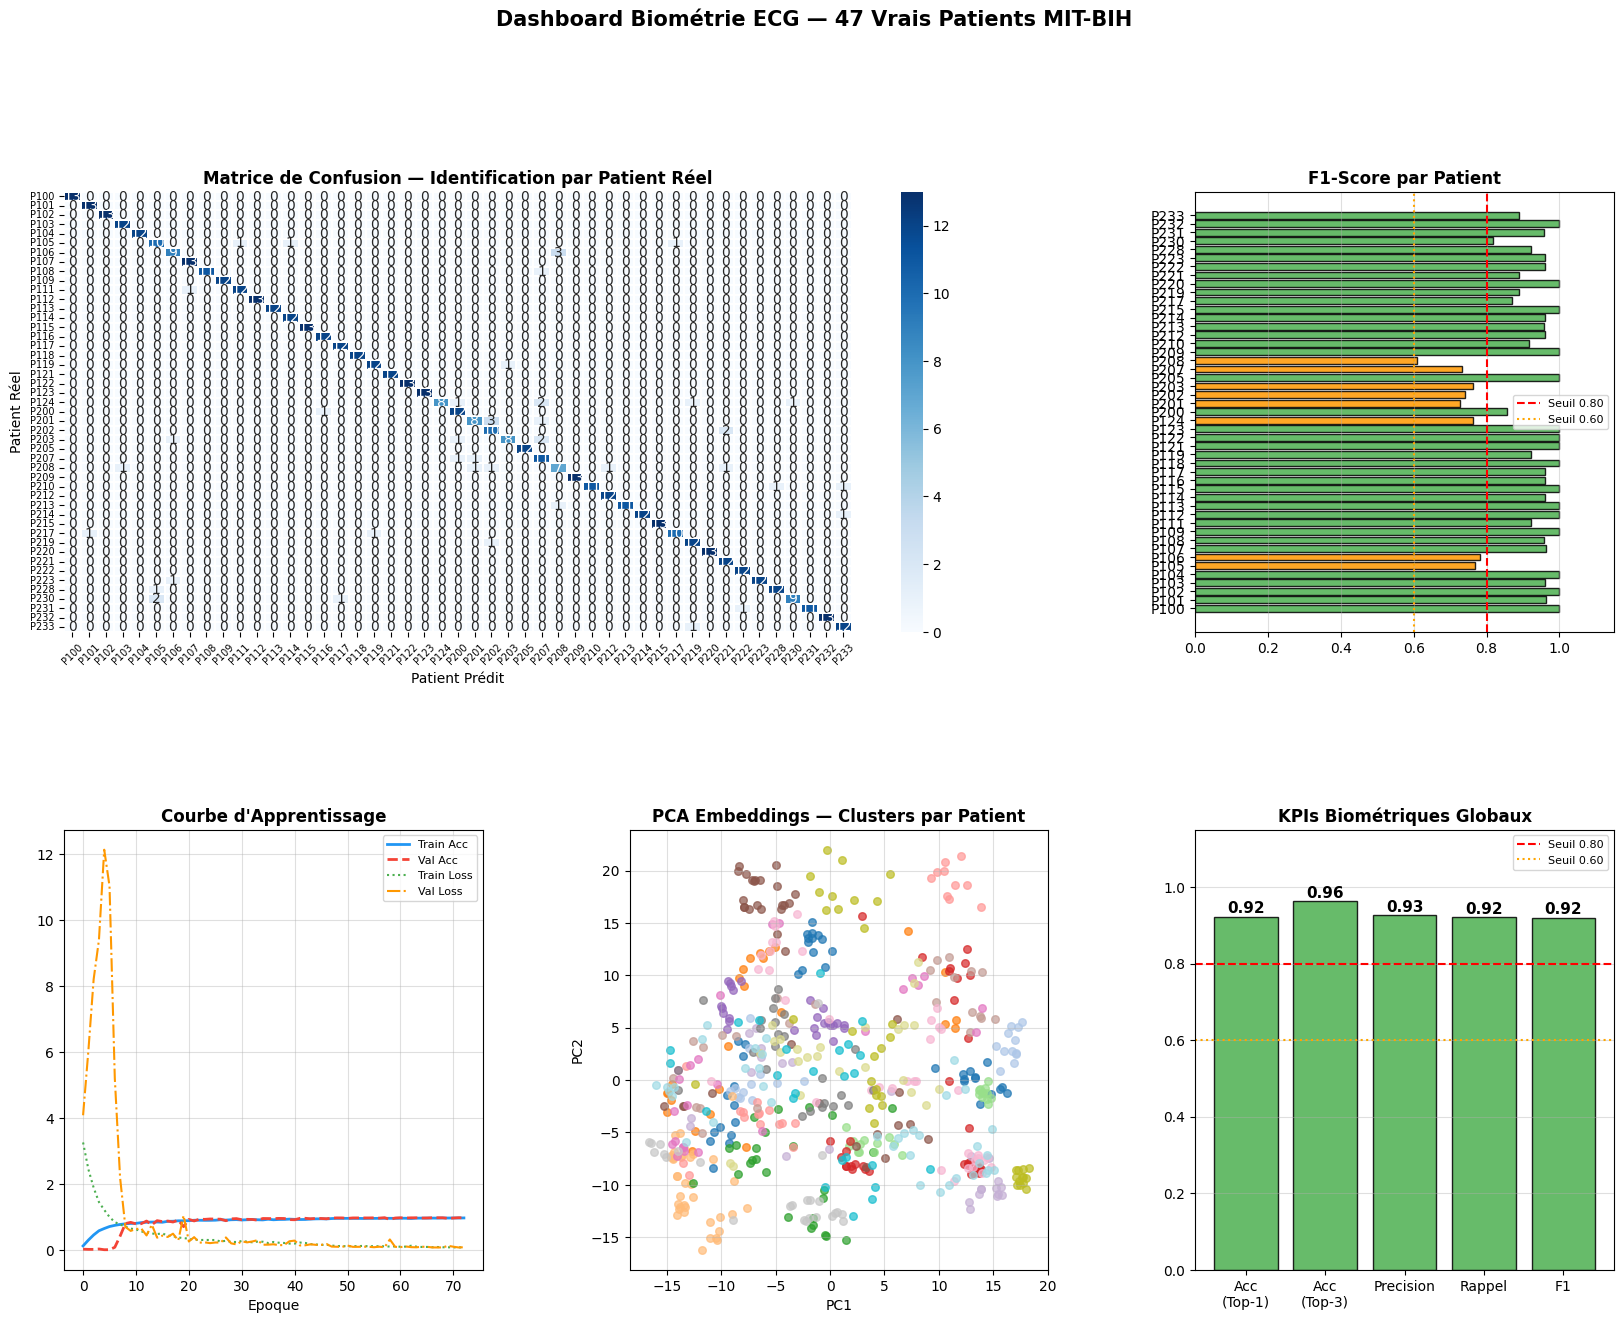

Dashboard final sauvegardé !


In [38]:
# ================================================================
# CELLULE 5 — ÉVALUATION COMPLÈTE
# ================================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA

# Prédictions
y_pred_proba = bio_net.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Métriques
acc   = accuracy_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='macro', zero_division=0)
prec  = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec   = recall_score(y_test, y_pred, average='macro', zero_division=0)
top3  = np.mean([y_test[i] in np.argsort(y_pred_proba[i])[-3:]
                 for i in range(len(y_test))])

print("\n" + "="*65)
print("   RAPPORT FINAL — IDENTIFICATION BIOMÉTRIQUE ECG RÉELLE")
print("="*65)
print(f"\n  Accuracy (Top-1)   : {acc*100:.2f}%")
print(f"  Accuracy (Top-3)   : {top3*100:.2f}%")
print(f"  Precision (macro)  : {prec:.4f}")
print(f"  Rappel (macro)     : {rec:.4f}")
print(f"  F1-Score (macro)   : {f1:.4f}")
verdict = "EXCELLENT" if acc>=0.80 else "BON" if acc>=0.65 else "ACCEPTABLE"
print(f"\n  Verdict : {verdict}")
print("="*65)

# ---- DASHBOARD FINAL ----
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# 1. Matrice confusion
ax1 = fig.add_subplot(gs[0, :2])
cm  = confusion_matrix(y_test, y_pred)
# Fix: Map re-encoded label 'i' back to original 'p_idx' for patient_info access
p_labels = [f"P{patient_info[le.inverse_transform([i])[0]]['record']}" for i in range(NUM_PATIENTS)]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=p_labels, yticklabels=p_labels,
            linewidths=0.3)
ax1.set_title('Matrice de Confusion — Identification par Patient Réel',
              fontweight='bold', fontsize=12)
ax1.set_ylabel('Patient Réel'); ax1.set_xlabel('Patient Prédit')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, fontsize=7)
plt.setp(ax1.yaxis.get_majorticklabels(), rotation=0, fontsize=7)

# 2. F1 par patient
ax2 = fig.add_subplot(gs[0, 2])
f1_per = f1_score(y_test, y_pred, average=None, zero_division=0)
colors_bar = ['#4CAF50' if f>=0.80 else '#FF9800' if f>=0.60 else '#F44336'
              for f in f1_per]
ax2.barh(p_labels, f1_per, color=colors_bar, edgecolor='k', alpha=0.85)
ax2.axvline(0.80, color='red',    linestyle='--', lw=1.5, label='Seuil 0.80')
ax2.axvline(0.60, color='orange', linestyle=':',  lw=1.5, label='Seuil 0.60')
ax2.set_title('F1-Score par Patient', fontweight='bold')
ax2.set_xlim(0, 1.15); ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.4)

# 3. Courbe apprentissage
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history_bio.history['accuracy'],     '#2196F3', lw=2, label='Train Acc')
ax3.plot(history_bio.history['val_accuracy'], '#F44336', lw=2,
         label='Val Acc', linestyle='--')
ax3.plot(history_bio.history['loss'],         '#4CAF50', lw=1.5,
         label='Train Loss', linestyle=':')
ax3.plot(history_bio.history['val_loss'],     '#FF9800', lw=1.5,
         label='Val Loss', linestyle='-.')
ax3.set_title("Courbe d'Apprentissage", fontweight='bold')
ax3.set_xlabel('Epoque'); ax3.legend(fontsize=8); ax3.grid(alpha=0.4)

# 4. PCA embeddings
ax4 = fig.add_subplot(gs[1, 1])
encoder_only = Model(inputs=bio_net.input,
                     outputs=bio_net.layers[-2].output)
emb_test = encoder_only.predict(X_test, verbose=0)
pca2d    = PCA(n_components=2).fit_transform(emb_test)
cmap_p   = plt.cm.tab20(np.linspace(0, 1, NUM_PATIENTS))
for p_id in range(NUM_PATIENTS):
    mask = y_test == p_id
    if mask.sum() > 0:
        # Fix: Map re-encoded label 'p_id' back to original 'p_idx' for patient_info access
        ax4.scatter(pca2d[mask,0], pca2d[mask,1],
                    color=cmap_p[p_id], alpha=0.7, s=30,
                    label=f'P{patient_info[le.inverse_transform([p_id])[0]]["record"]}')
ax4.set_title('PCA Embeddings — Clusters par Patient', fontweight='bold')
ax4.set_xlabel('PC1'); ax4.set_ylabel('PC2')
ax4.grid(alpha=0.4)

# 5. KPIs globaux
ax5 = fig.add_subplot(gs[1, 2])
kpi_names  = ['Acc\n(Top-1)', 'Acc\n(Top-3)', 'Precision', 'Rappel', 'F1']
kpi_values = [acc, top3, prec, rec, f1]
bar_colors = ['#4CAF50' if v>=0.80 else '#FF9800' if v>=0.60 else '#F44336'
              for v in kpi_values]
bars = ax5.bar(kpi_names, kpi_values, color=bar_colors, edgecolor='k', alpha=0.85)
ax5.axhline(0.80, color='red',    linestyle='--', lw=1.5, label='Seuil 0.80')
ax5.axhline(0.60, color='orange', linestyle=':',  lw=1.5, label='Seuil 0.60')
ax5.set_ylim(0, 1.15); ax5.legend(fontsize=8); ax5.grid(axis='y', alpha=0.4)
ax5.set_title('KPIs Biométriques Globaux', fontweight='bold')
for bar, val in zip(bars, kpi_values):
    ax5.text(bar.get_x()+bar.get_width()/2, val+0.01,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle(f'Dashboard Biométrie ECG — {NUM_PATIENTS} Vrais Patients MIT-BIH',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('biometric_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard final sauvegardé !")

   DEMO LIVE — Identification Patient Inconnu

  Patient réel      : P102
  Patient identifié : P102
  Confiance         : 100.0%
  Résultat          : CORRECT

  Top-3 :
    1. P102 : 100.0% <-- CORRECT
    2. P104 : 0.0%
    3. P222 : 0.0%


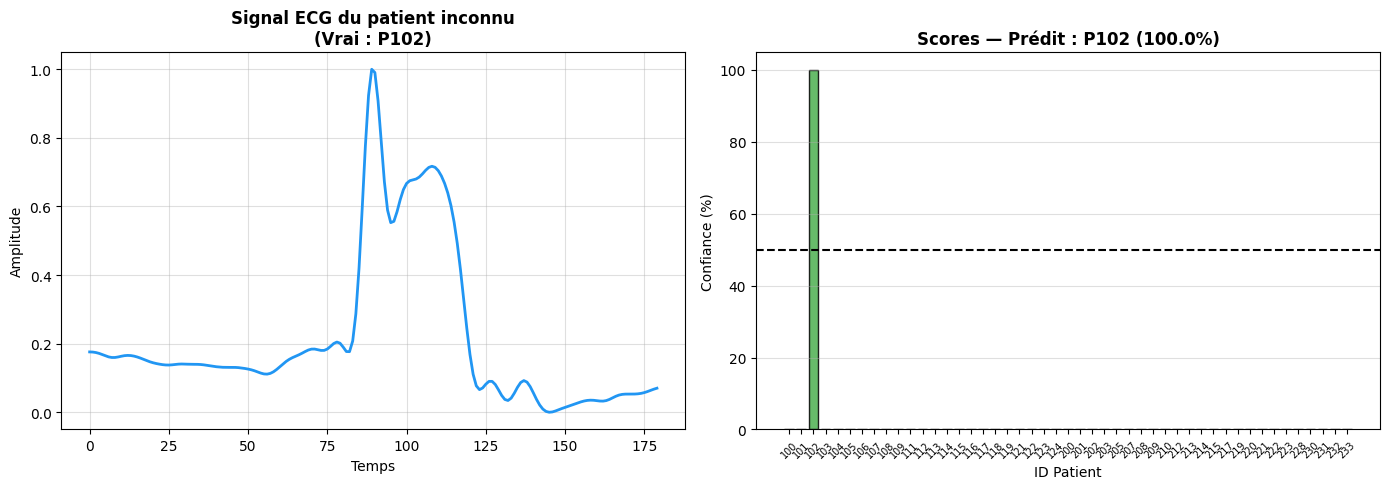


Modèles sauvegardés !
  ecg_biometric_net.keras
  biometric_config.pkl

Projet 6 TERMINÉ — Prêt pour l'interface Streamlit + AI Agents !


In [40]:
# ================================================================
# CELLULE 6 — DEMO LIVE + Sauvegarde
# ================================================================
import joblib

print("="*60)
print("   DEMO LIVE — Identification Patient Inconnu")
print("="*60)

test_idx     = np.random.randint(0, len(X_test))
true_patient = y_test[test_idx]
signal_test  = X_test[test_idx:test_idx+1]

pred_proba   = bio_net.predict(signal_test, verbose=0)[0]
top3_idx     = np.argsort(pred_proba)[::-1][:3]
pred_patient = top3_idx[0]

# Fix: Use le.inverse_transform to get the original p_idx
original_true_patient_p_idx = le.inverse_transform([true_patient])[0]
original_pred_patient_p_idx = le.inverse_transform([pred_patient])[0]

print(f"\n  Patient réel      : P{patient_info[original_true_patient_p_idx]['record']}")
print(f"  Patient identifié : P{patient_info[original_pred_patient_p_idx]['record']}")
print(f"  Confiance         : {pred_proba[pred_patient]*100:.1f}%")
print(f"  Résultat          : {'CORRECT' if pred_patient==true_patient else 'INCORRECT'}")
print(f"\n  Top-3 :")
for rank, idx in enumerate(top3_idx):
    # Fix: Use le.inverse_transform for idx as well
    original_idx_p_idx = le.inverse_transform([idx])[0]
    marker = " <-- CORRECT" if idx == true_patient else ""
    print(f"    {rank+1}. P{patient_info[original_idx_p_idx]['record']} : "
          f"{pred_proba[idx]*100:.1f}%{marker}")

# Graphe demo
fig, (ax_sig, ax_conf) = plt.subplots(1, 2, figsize=(14, 5))

ax_sig.plot(X_test[test_idx].flatten(), color='#2196F3', lw=2)
ax_sig.set_title(f"Signal ECG du patient inconnu\n"
                 f"(Vrai : P{patient_info[original_true_patient_p_idx]['record']})",
                 fontweight='bold')
ax_sig.set_xlabel("Temps"); ax_sig.set_ylabel("Amplitude")
ax_sig.grid(alpha=0.4)

bar_cols = ['#4CAF50' if i==true_patient else
            '#F44336' if i==pred_patient and i!=true_patient else
            '#BBDEFB' for i in range(NUM_PATIENTS)]
ax_conf.bar(range(NUM_PATIENTS), pred_proba*100,
            color=bar_cols, edgecolor='k', alpha=0.85)
ax_conf.axhline(50, color='k', linestyle='--', lw=1.5)
ax_conf.set_xlabel("ID Patient"); ax_conf.set_ylabel("Confiance (%)")
ax_conf.set_title(f"Scores — Prédit : P{patient_info[original_pred_patient_p_idx]['record']} "
                  f"({pred_proba[pred_patient]*100:.1f}%)",
                  fontweight='bold')
ax_conf.set_xticks(range(NUM_PATIENTS))
# Fix: Use le.inverse_transform to get the original p_idx for x-tick labels
ax_conf.set_xticklabels([patient_info[le.inverse_transform([i])[0]]['record'] for i in range(NUM_PATIENTS)],
                         rotation=45, fontsize=7)
ax_conf.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('demo_identification.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarde complète
bio_net.save('ecg_biometric_net.keras')
joblib.dump({'num_patients': NUM_PATIENTS,
             'patient_info': patient_info,
             'beat_len': BEAT_LEN,
             'le_classes': le.classes_.tolist()}, 'biometric_config.pkl')
print("\nModèles sauvegardés !")
print("  ecg_biometric_net.keras")
print("  biometric_config.pkl")
